In [1]:
from utils.chart import *
from utils.imports import *

chart 로드 완료
imports 로드 완료


# 1. 데이터 로딩 및 정보 확인

In [2]:
# 데이터 로드 경로
DATA_PATH = Path('data/Bank Customer Churn Prediction.csv')


# 데이터 로드 실패 시 오류 메세지
if not DATA_PATH.exists():
    raise FileNotFoundError(f"파일을 찾을 수 없습니다. : {DATA_PATH}")


# 데이터 로드
df = pd.read_csv(DATA_PATH,
                 encoding = "utf-8",
                 sep = ",",
                 na_values = ["", "NA", "NULL", "None"])


# 데이터 로드 메세지
print(f"데이터 로드 완료! : {df.shape[0]:,}행, {df.shape[1]}열")


# 데이터 컬럼 정리
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


print("="*12+"데이터셋 기본 정보"+"="*12)


# 데이터 기본 정보
print(df.info())            # 결측치는 없는 것으로 확인
                            # gender, country (object)확인
                            # 추후 맵핑을 하거나 OneHot 쓰면 될 것 같음 (아니면 상관관계 적으면 그냥 컬럼 제거)

데이터 로드 완료! : 10,000행, 12열
============데이터셋 기본 정보============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


# 2. 각 종 그래프 그려보기

============ bar_pie_graph ============


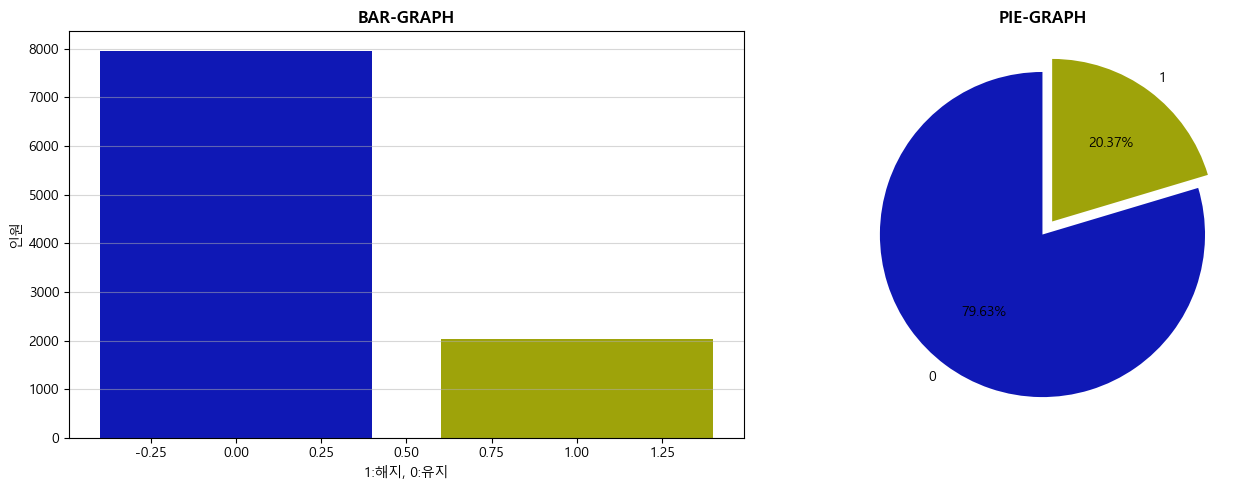



============ boxplot_graph ============


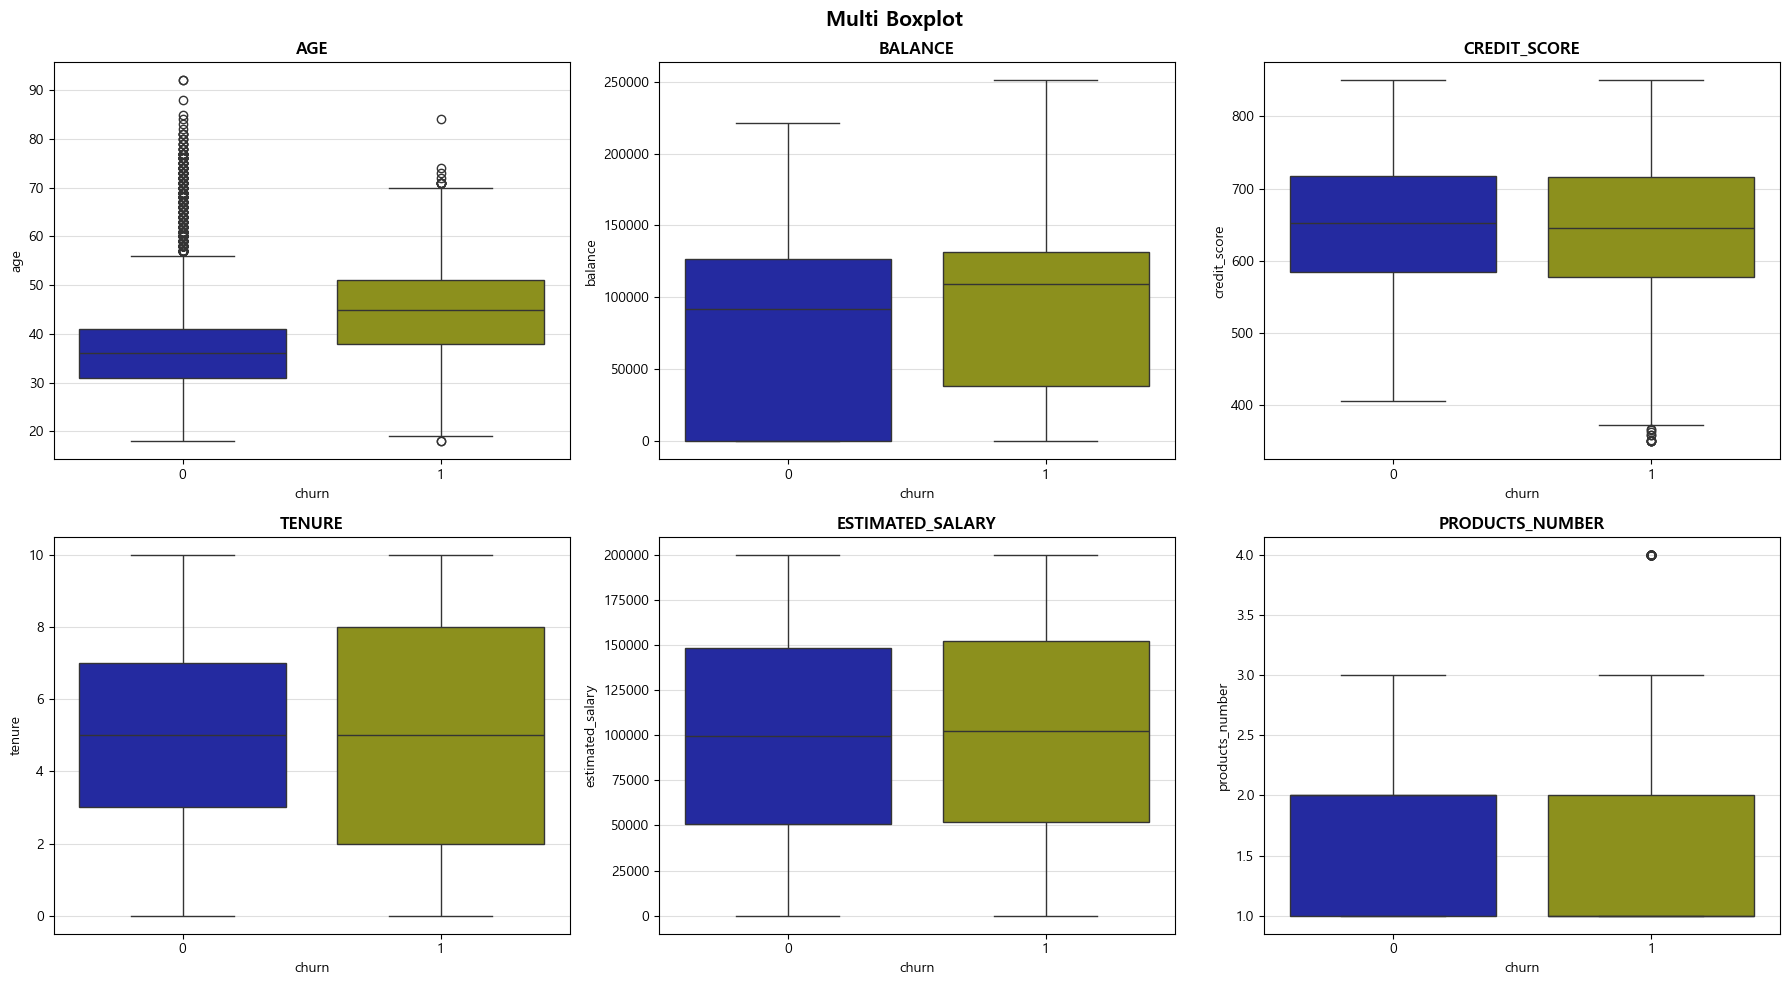



============ heatmap_graph ============


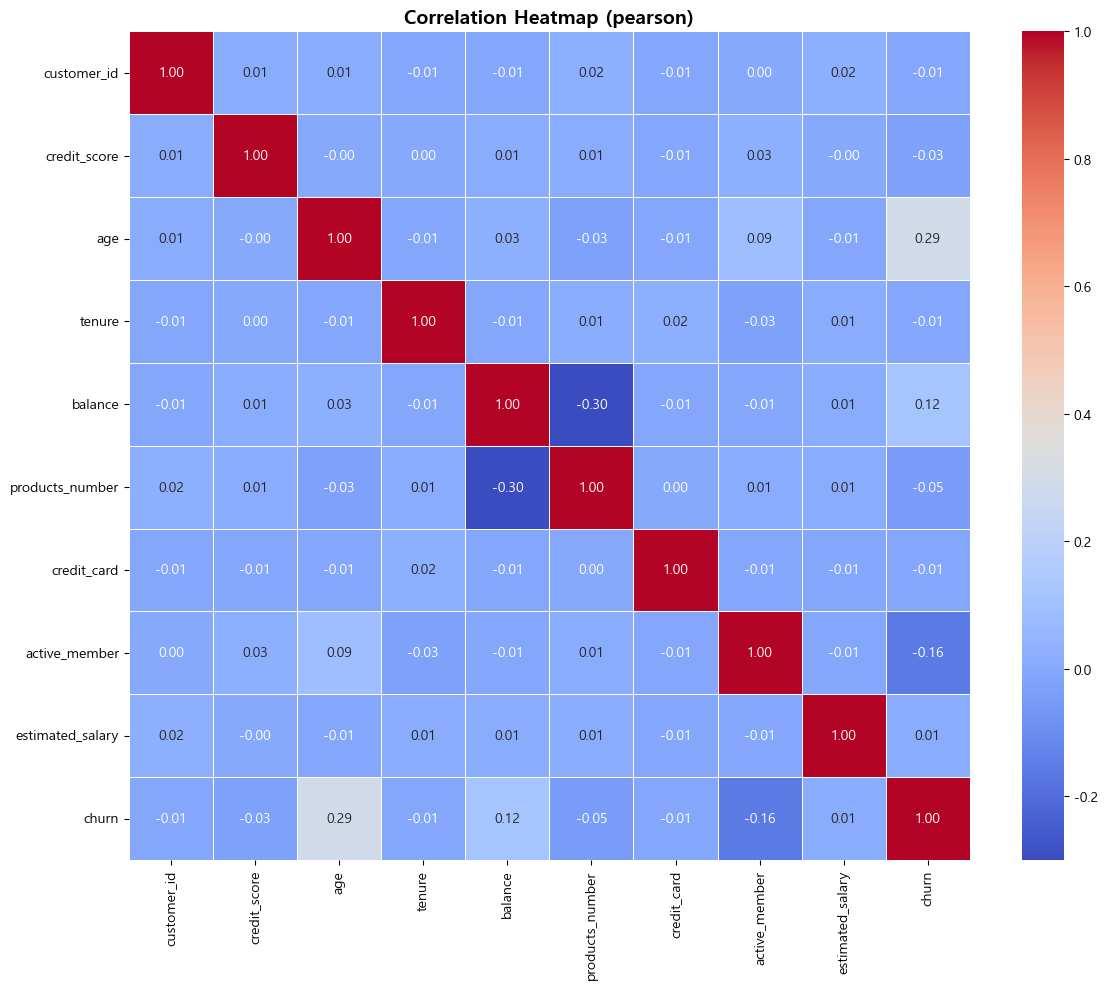



============ hist_graph ============


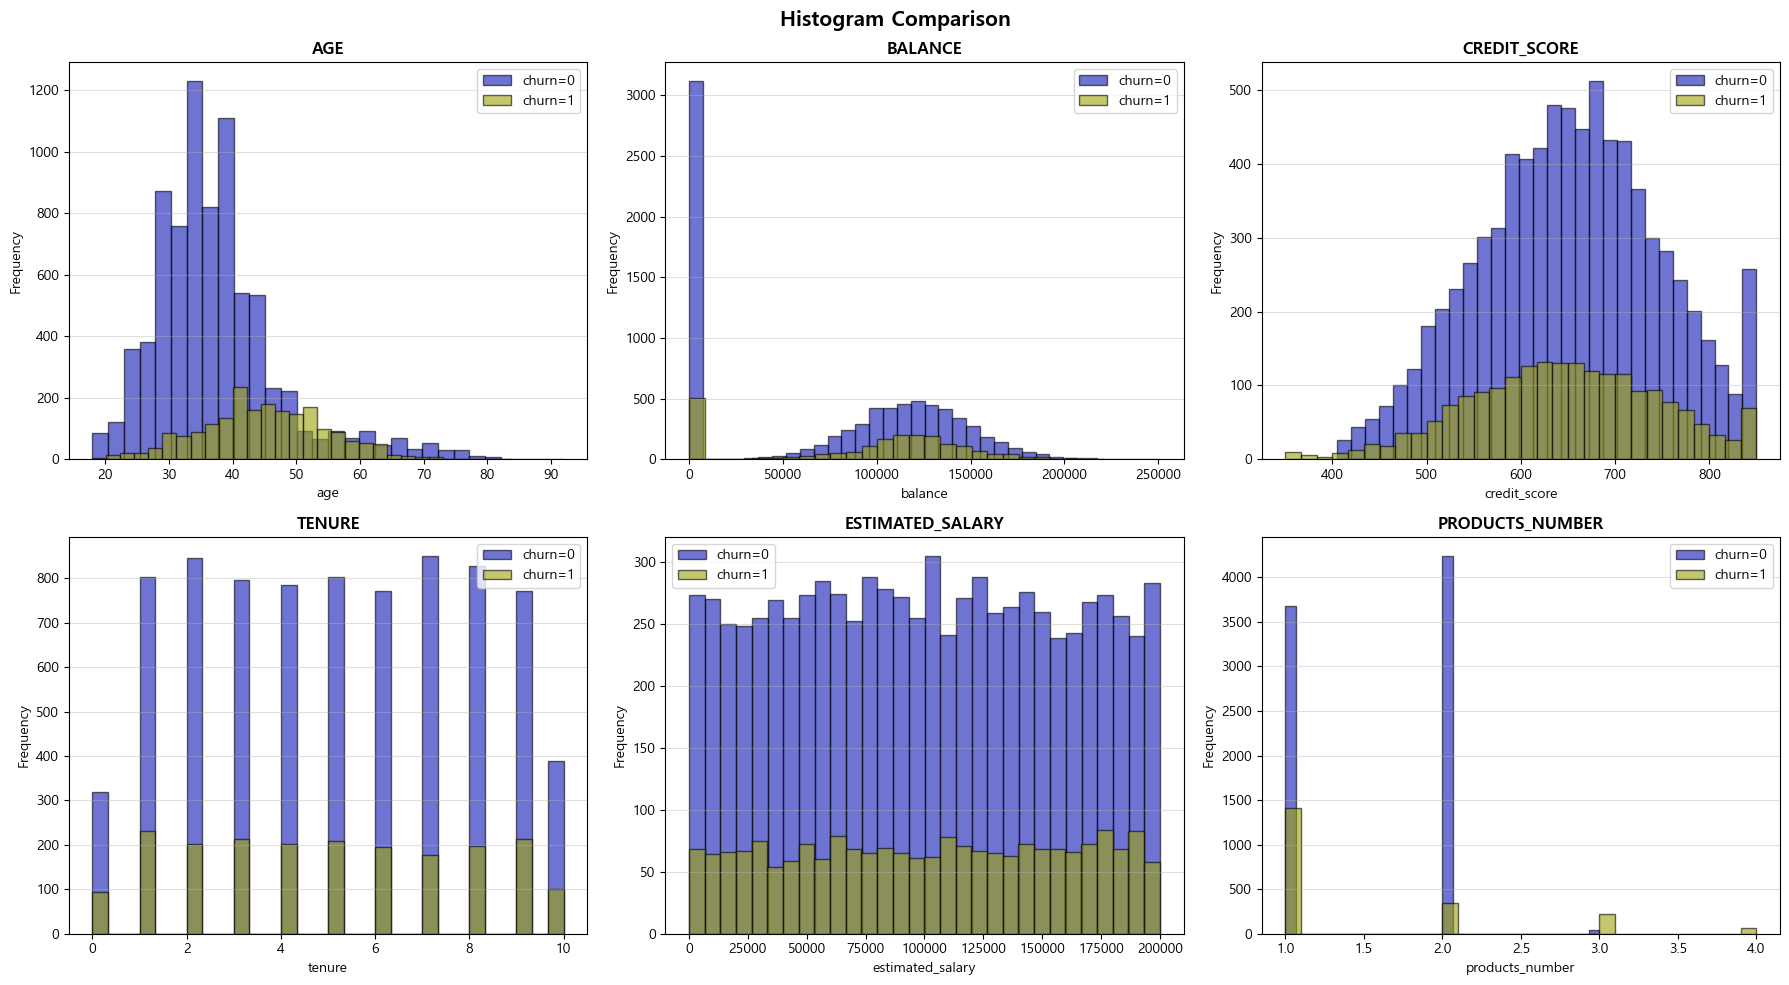

In [3]:
chart = ChartMaker(df)

# 1. bar_pie
# 2. boxplot
# 3. heatmap
# 4. hist

print("="*12,"bar_pie_graph","="*12)
bar_pie = chart.bar_pie()
print("\n")
print("="*12,"boxplot_graph","="*12)
boxplot = chart.boxplot()
print("\n")
print("="*12,"heatmap_graph","="*12)
heatmap = chart.heatmap()
print("\n")
print("="*12,"hist_graph","="*12)
hist = chart.hist()
print("\n")

# 3. 전처리

In [4]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['20-', '20s', '30s', '40s', '50s', '60+']
)


Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1
df['balance_clipped'] = df['balance'].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)


df['balance_to_salary'] = df['balance'] / (df['estimated_salary'] + 1)
df['credit_to_age'] = df['credit_score'] / (df['age'] + 1)
df['tenure_to_age'] = df['tenure'] / (df['age'] + 1)
# df['age_x_active'] = df['age'] * df['active_member']
# df['salary_x_active'] = df['estimated_salary'] * df['active_member']
df['balance_x_age'] = df['balance_clipped'] * df['age']
df['log_balance'] = np.log1p(df['balance_clipped'])
df['log_salary'] = np.log1p(df['estimated_salary'])
df['salary_group'] = pd.qcut(df['estimated_salary'], q=5, labels=False)


drop_cols = ["customer_id", "active_member", "credit_card", "churn"]

X = df.drop(drop_cols, axis=1)
y = df["churn"]

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [col for col in X.columns if col not in cat_cols]

print(cat_cols)
print(num_cols)

['country', 'gender', 'age_group']
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'estimated_salary', 'balance_clipped', 'balance_to_salary', 'credit_to_age', 'tenure_to_age', 'balance_x_age', 'log_balance', 'log_salary', 'salary_group']


In [5]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ]
)

In [6]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)


print("train:", X_train.shape, "val:", X_val.shape, "test:", X_test.shape)

train: (5625, 17) val: (1875, 17) test: (2500, 17)


# 4. 모델 생성

In [7]:
# neg = (y_train == 0).sum()
# pos = (y_train == 1).sum()
# scale_pos_weight = neg / pos




rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced"
    )


lr = LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        class_weight="balanced"
    )


xgb = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="auc",
        random_state=42,
        tree_method="hist"
        # scale_pos_weight=scale_pos_weight
    )

# 5. 파이프 라인 생성

In [8]:
model_rf = Pipeline([
    ("pre", preprocess),
    ("model", rf),
])
model_rf.fit(X_train, y_train)
print("rf_train score:", model_rf.score(X_train, y_train))
print("rf_val score:", model_rf.score(X_val, y_val))



model_lr = Pipeline([
    ("pre", preprocess),
    ("model", lr),
])
model_lr.fit(X_train, y_train)
print("lr_train score:", model_lr.score(X_train, y_train))
print("lr_val score:", model_lr.score(X_val, y_val))



model_xgb = Pipeline([
    ("pre", preprocess),
    ("model", xgb),
])
model_xgb.fit(X_train, y_train)
print("xgb_train score:", model_xgb.score(X_train, y_train))
print("xgb_val score:", model_xgb.score(X_val, y_val))

rf_train score: 0.9084444444444445
rf_val score: 0.8272
lr_train score: 0.7244444444444444
lr_val score: 0.7072
xgb_train score: 0.9064888888888889
xgb_val score: 0.8517333333333333


# 6. 그리드서치

In [9]:
param_grid = {
    "model__n_estimators": [200, 400, 700],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.01, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
}

grid_xgb = GridSearchCV(
    estimator=model_xgb,     
    param_grid=param_grid,
    scoring="roc_auc",       
    cv=3,                    
    n_jobs=-1,              
    verbose=1,
)

grid_xgb.fit(X_train, y_train)

print("Best params:", grid_xgb.best_params_)
print("Best CV AUC:", grid_xgb.best_score_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 400, 'model__subsample': 0.8}
Best CV AUC: 0.8473492937957122


In [ ]:
best_xgb = grid_xgb.best_estimator_


# y_val_pred = best_xgb.predict(X_val)
y_val_proba = best_xgb.predict_proba(X_val)[:, 1]


threshold = 0.30
y_val_pred = (y_val_proba >= threshold).astype(int)


val_acc   = accuracy_score(y_val, y_val_pred)
val_pre   = precision_score(y_val, y_val_pred)
val_rec   = recall_score(y_val, y_val_pred)
val_f1    = f1_score(y_val, y_val_pred)
val_auc   = roc_auc_score(y_val, y_val_proba)

print("=== XGB Val Metrics ===")
print(f"Accuracy : {val_acc:.4f}")
print(f"Precision: {val_pre:.4f}")
print(f"Recall   : {val_rec:.4f}")
print(f"F1-score : {val_f1:.4f}")
print(f"ROC AUC  : {val_auc:.4f}")

=== XGB Val Metrics ===
Accuracy : 0.8208
Precision: 0.5498
Recall   : 0.6649
F1-score : 0.6019
ROC AUC  : 0.8502


# 7. ROC 커브 그리기


Confusion Matrix:
[[1434   59]
 [ 217  165]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1493
           1       0.74      0.43      0.54       382

    accuracy                           0.85      1875
   macro avg       0.80      0.70      0.73      1875
weighted avg       0.84      0.85      0.84      1875



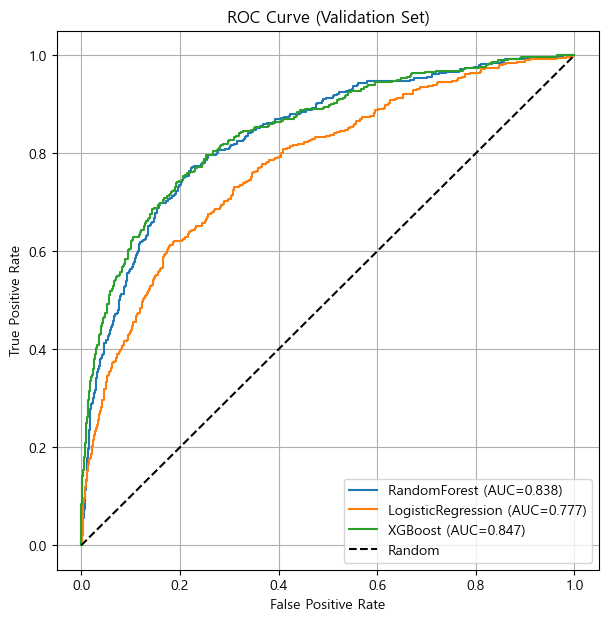

In [11]:
cm = confusion_matrix(y_val, y_val_pred)
print("\nConfusion Matrix:")
print(cm)


print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))


models = {
    "RandomForest": model_rf,
    "LogisticRegression": model_lr,
    "XGBoost": model_xgb
}

plt.figure(figsize=(7, 7))

for name, model in models.items():
   
    y_val_proba = model.predict_proba(X_val)[:, 1]

   
    fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

   
    auc_score = roc_auc_score(y_val, y_val_proba)

    
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})")


plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.title("ROC Curve (Validation Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

# 8. 모델 최종 테스트

In [ ]:
results = {}

for name, model in models.items():
   
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    pre  = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_proba)

    results[name] = {
        "Accuracy": acc,
        "Precision": pre,
        "Recall": rec,
        "F1": f1,
        "AUC": auc
    }



for model_name, metrics in results.items():
    print(f"\n==== {model_name} ====")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")


==== RandomForest ====
Accuracy: 0.8304
Precision: 0.5780
Recall: 0.6189
F1: 0.5977
AUC: 0.8477

==== LogisticRegression ====
Accuracy: 0.7152
Precision: 0.3898
Recall: 0.7053
F1: 0.5021
AUC: 0.7827

==== XGBoost ====
Accuracy: 0.8536
Precision: 0.7061
Recall: 0.4813
F1: 0.5724
AUC: 0.8519


# 9. 모델 저장

In [13]:
import pickle
import os


os.makedirs("models", exist_ok=True)

models = {
    "RandomForest": model_rf,
    "LogisticRegression": model_lr,
    "XGBoost": model_xgb
}

for name, model in models.items():
    file_path = f"models/{name.lower()}_model.pkl"
    with open(file_path, "wb") as f:
        pickle.dump(model, f)
    print(f"Saved: {file_path}")

Saved: models/randomforest_model.pkl
Saved: models/logisticregression_model.pkl
Saved: models/xgboost_model.pkl


In [14]:
import pandas as pd
import os


SAVE_DIR = "data"
os.makedirs(SAVE_DIR, exist_ok=True)


pd.DataFrame(y_val).to_csv(f"{SAVE_DIR}/y_valid.csv", index=False)
pd.DataFrame(y_test).to_csv(f"{SAVE_DIR}/y_test.csv", index=False)


val_pred = model_xgb.predict(X_val)
val_proba = model_xgb.predict_proba(X_val)[:, 1]


pd.DataFrame(val_pred, columns=["pred"]).to_csv(f"{SAVE_DIR}/xgb_valid_pred.csv", index=False)
pd.DataFrame(val_proba, columns=["proba"]).to_csv(f"{SAVE_DIR}/xgb_valid_proba.csv", index=False)


test_pred = model_xgb.predict(X_test)
test_proba = model_xgb.predict_proba(X_test)[:, 1]


pd.DataFrame(test_pred, columns=["pred"]).to_csv(f"{SAVE_DIR}/xgb_test_pred.csv", index=False)
pd.DataFrame(test_proba, columns=["proba"]).to_csv(f"{SAVE_DIR}/xgb_test_proba.csv", index=False)


print("저장 완료")

저장 완료
